<a href="https://colab.research.google.com/github/gkibria121/data-science/blob/main/AI_Voice_Detector.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [88]:
"""
AI vs Real Voice Detection System
Organized with proper OOP structure and comprehensive logging
"""

import os
import random
import glob
import hashlib
import warnings
import logging
import sys
from datetime import datetime
from typing import List, Dict, Tuple, Optional

import time
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from PIL import Image, ImageFile
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, auc
)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchaudio
import soundfile as sf
import torchvision.transforms as T
from torchvision.models import (
    resnet18, efficientnet_b0, efficientnet_b1,
    densenet121, densenet169, mobilenet_v3_small,
    convnext_tiny, vit_b_16, swin_t
)

# Critical stability settings
ImageFile.LOAD_TRUNCATED_IMAGES = True
warnings.filterwarnings('ignore')
os.environ['TORCHAUDIO_USE_BACKEND_DISPATCHER'] = '0'

In [89]:
# ============================================================================
# LOGGING SETUP
# ============================================================================
class LoggerSetup:
    """Configure logging for the entire application"""

    @staticmethod
    def setup_logger(
        log_file: str = "log.txt",
        level=logging.INFO,
        console: bool = True
    ):
        """Setup logger with file handler, optionally console output"""
        logger = logging.getLogger('AIVoiceDetection')
        logger.setLevel(level)
        logger.handlers.clear()

        # Formatter for file
        detailed_formatter = logging.Formatter(
            '%(asctime)s - %(name)s - %(levelname)s - %(funcName)s:%(lineno)d - %(message)s',
            datefmt='%Y-%m-%d %H:%M:%S'
        )

        # File handler
        file_handler = logging.FileHandler(log_file, mode='a', encoding='utf-8')
        file_handler.setLevel(logging.DEBUG)
        file_handler.setFormatter(detailed_formatter)
        logger.addHandler(file_handler)

        # Optional console handler
        if console:
            simple_formatter = logging.Formatter(
                '%(asctime)s - %(levelname)s - %(message)s',
                datefmt='%H:%M:%S'
            )
            console_handler = logging.StreamHandler(sys.stdout)
            console_handler.setLevel(logging.INFO)
            console_handler.setFormatter(simple_formatter)
            logger.addHandler(console_handler)

        # Log initial setup
        logger.info("="*80)
        logger.info(f"Logging initialized - Session started at {datetime.now()}")
        logger.info("="*80)

        return logger

# Example usage
logger = LoggerSetup.setup_logger(console=False)  # Console logging OFF

INFO:AIVoiceDetection:================================================================================
INFO:AIVoiceDetection:Logging initialized - Session started at 2025-11-10 10:56:33.593365
INFO:AIVoiceDetection:================================================================================


In [90]:
# ============================================================================
# CONFIGURATION
# ============================================================================

class Config:
    """Central configuration for the entire pipeline"""

    # Paths
    COMBINED_DIR = r"./dataset"
    AI_DIR = os.path.join(COMBINED_DIR, "ai")
    REAL_DIR = os.path.join(COMBINED_DIR, "real")
    CLEAN_DIR = os.path.join("./output", "clean_audio_unique")
    IMG_DIR = os.path.join("./output", "spectrogram_images_clean_unique")
    SPLIT_DIR = os.path.join("./output", "_splits")

    # Audio settings
    SR = 16000
    N_FFT = 1024
    HOP = 160
    N_MELS = 128
    F_MIN = 20.0
    F_MAX = SR / 2 - 20.0

    # Denoising settings
    DENOISE_WIN = 1024
    DENOISE_HOP = 256
    DENOISE_NOISE_FRAMES = 20
    DENOISE_THRESH_DB = 6.0
    DENOISE_ATTEN_DB = 20.0

    # VAD settings
    VAD_FRAME_MS = 20
    VAD_THR_RATIO = 0.5
    VAD_PAD_MS = 100

    # Preprocessing
    PRE_EMPH = 0.97
    HPF_CUTOFF = 40.0
    MIN_SAMPLES = HOP * 6

    # Training settings
    IMG_SIZE = 224
    BATCH_SIZE = 64
    NUM_WORKERS = 0  # Windows/Jupyter compatibility
    EPOCHS = 12
    LR = 3e-4
    WEIGHT_DECAY = 1e-4
    PATIENCE = 3

    # System
    SEED = 42
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

    # Audio extensions
    AUDIO_EXTS = (".wav", ".mp3", ".flac", ".m4a", ".ogg", ".aac", ".wma",
                  ".WAV", ".MP3", ".FLAC", ".M4A", ".OGG", ".AAC", ".WMA")

    @classmethod
    def setup_environment(cls):
        """Initialize environment settings"""
        logger.info("Setting up environment...")

        random.seed(cls.SEED)
        np.random.seed(cls.SEED)
        torch.manual_seed(cls.SEED)
        torch.set_num_threads(4)

        logger.info(f"Random seed set to: {cls.SEED}")
        logger.info(f"Device: {cls.DEVICE}")

        if cls.DEVICE == "cuda":
            torch.backends.cudnn.benchmark = True
            logger.info(f"CUDA available - GPU: {torch.cuda.get_device_name(0)}")
            logger.info(f"CUDA version: {torch.version.cuda}")

        # Create directories
        for d in [cls.CLEAN_DIR, cls.IMG_DIR, cls.SPLIT_DIR]:
            os.makedirs(d, exist_ok=True)
            logger.debug(f"Directory ensured: {d}")

        logger.info("Environment setup complete")

In [91]:
# ============================================================================
# UTILITY FUNCTIONS
# ============================================================================

class FileUtils:
    """File and path utilities"""

    @staticmethod
    def list_audio_files(folder: str, exts: tuple = Config.AUDIO_EXTS) -> List[str]:
        """Recursively list all audio files in folder"""
        logger.debug(f"Scanning for audio files in: {folder}")
        files = []

        for ext in exts:
            found = glob.glob(os.path.join(folder, f"**/*{ext}"), recursive=True)
            files.extend(found)
            if found:
                logger.debug(f"Found {len(found)} files with extension {ext}")

        logger.info(f"Total audio files found in {folder}: {len(files)}")
        return files

    @staticmethod
    def list_image_files(folder: str, exts: tuple = (".png", ".jpg", ".jpeg")) -> List[str]:
        """Recursively list all image files in a folder"""
        logger.debug(f"Scanning for image files in: {folder}")
        files = []
        for ext in exts:
            found = glob.glob(os.path.join(folder, f"**/*{ext}"), recursive=True)
            files.extend(found)

        logger.info(f"Total image files found in {folder}: {len(files)}")
        return files

    @staticmethod
    def unique_output_name(src_path: str) -> str:
        """Generate unique output name: <basename>__<ext>__<hash>.wav"""
        base, ext = os.path.splitext(os.path.basename(src_path))
        # Include timestamp (milliseconds)
        unique_str = f"{os.path.abspath(src_path)}_{time.time_ns()}"
        h = hashlib.sha1(unique_str.encode("utf-8")).hexdigest()[:10]
        name = f"{base}__{ext.lstrip('.').lower()}__{h}.wav"
        logger.debug(f"Generated unique name: {name}")
        return name

In [92]:
# ============================================================================
# AUDIO PROCESSING
# ============================================================================

class AudioLoader:
    """Load any audio file robustly using multiple fallback methods"""

    def __init__(self, target_sr: int = 16000, device: str = "cuda"):
        self.target_sr = target_sr
        self.device = device
        logger.debug(f"AudioLoader initialized - SR: {target_sr}, Device: {device}")

    @torch.no_grad()
    def load(self, path: str) -> torch.Tensor:
        logger.debug(f"Loading audio: {path}")

        # Try torchaudio first
        try:
            wav, sr = torchaudio.load(path)
            if wav.shape[0] > 1:
                wav = wav.mean(dim=0, keepdim=True)
                logger.debug("Converted stereo to mono")
            if sr != self.target_sr:
                wav = torchaudio.functional.resample(wav, sr, self.target_sr)
                logger.debug(f"Resampled from {sr}Hz to {self.target_sr}Hz")
            mx = torch.amax(torch.abs(wav))
            if mx > 0: wav = wav / mx
            logger.debug(f"Successfully loaded with torchaudio - shape: {wav.shape}")
            return wav.to(self.device)
        except Exception as e:
            logger.debug(f"Torchaudio failed: {str(e)}")

        # Try soundfile
        try:
            y, sr = sf.read(path, dtype="float32", always_2d=False)
            if y.ndim == 2: y = y.mean(axis=1)
            wav = torch.from_numpy(y).unsqueeze(0)
            if sr != self.target_sr:
                wav = torchaudio.functional.resample(wav, sr, self.target_sr)
            mx = torch.amax(torch.abs(wav))
            if mx > 0: wav = wav / mx
            logger.debug(f"Successfully loaded with soundfile - shape: {wav.shape}")
            return wav.to(self.device)
        except Exception as e:
            logger.debug(f"Soundfile failed: {str(e)}")

        # Try librosa
        try:
            y, sr = librosa.load(path, sr=self.target_sr, mono=True)
            wav = torch.from_numpy(y.astype(np.float32)).unsqueeze(0).to(self.device)
            mx = torch.amax(torch.abs(wav))
            if mx > 0: wav = wav / mx
            logger.debug(f"Successfully loaded with librosa - shape: {wav.shape}")
            return wav
        except Exception as e:
            logger.error(f"All loading methods failed for {path}: {str(e)}")
            return None

    @staticmethod
    def _normalize(wav):
        mx = torch.amax(torch.abs(wav))
        return wav / (mx + 1e-8)


class AudioDenoiser:
    """Audio denoising with spectral gating and optional Demucs"""

    def __init__(self, device: str = Config.DEVICE):
        self.device = device
        self.window = torch.hann_window(Config.DENOISE_WIN, device=device)
        self.demucs_model = None
        self.demucs_apply_model = None
        self.demucs_ok = False
        self._init_demucs()
        logger.debug(f"AudioDenoiser initialized - Demucs available: {self.demucs_ok}")

    def _init_demucs(self):
        """Initialize Demucs model if available"""
        # First try to import apply_model
        try:
            from demucs.apply import apply_model
            self.demucs_apply_model = apply_model
        except ImportError:
            self.demucs_apply_model = None
            logger.debug("apply_model not available")

        # Then try to load the model
        try:
            from demucs.pretrained import get_model as demucs_get_model
            self.demucs_model = demucs_get_model("htdemucs")
            self.demucs_model.to(self.device).eval()
            self.demucs_ok = True
            logger.info("Demucs model loaded successfully (from pretrained)")
        except Exception as e:
            logger.debug(f"Demucs pretrained loading failed: {e}")
            try:
                self.demucs_model = torch.hub.load("facebookresearch/demucs:main", "htdemucs")
                self.demucs_model.to(self.device).eval()
                self.demucs_ok = True
                logger.info("Demucs model loaded successfully (from torch.hub)")
            except Exception as e2:
                logger.warning(f"Demucs not available: {e2}")
                self.demucs_ok = False

    @torch.no_grad()
    def denoise(self, wav: torch.Tensor, method: str = "auto") -> torch.Tensor:
        """Denoise audio"""
        logger.debug(f"Denoising with method: {method}")

        if method == "demucs":
            result = self._demucs_denoise(wav)
            if result is None:
                logger.error("Demucs denoising failed")
                raise RuntimeError("Demucs failed")
            return result
        elif method == "spectral":
            return self._spectral_gate(wav)
        else:  # auto
            result = self._demucs_denoise(wav)
            if result is not None:
                logger.debug("Used Demucs denoising")
                return result
            logger.debug("Falling back to spectral gating")
            return self._spectral_gate(wav)

    @torch.no_grad()
    def _spectral_gate(self, wav: torch.Tensor) -> torch.Tensor:
        """Spectral gating denoising"""
        logger.debug("Applying spectral gating")

        stft = torch.stft(
            wav, n_fft=Config.DENOISE_WIN, hop_length=Config.DENOISE_HOP,
            win_length=Config.DENOISE_WIN, window=self.window,
            center=True, return_complex=True
        )

        mag = torch.abs(stft) + 1e-8
        phase = stft / mag

        # Estimate noise
        N = min(Config.DENOISE_NOISE_FRAMES, mag.shape[-1])
        noise = mag[..., :N].median(dim=-1, keepdim=True).values

        # Apply gate
        mag_db = 20.0 * torch.log10(mag)
        noise_db = 20.0 * torch.log10(noise + 1e-8)
        keep = (mag_db - noise_db) >= Config.DENOISE_THRESH_DB
        atten = 10 ** (-Config.DENOISE_ATTEN_DB / 20.0)
        mag_dn = torch.where(keep, mag, mag * atten)

        # Reconstruct
        stft_dn = mag_dn * phase
        wav_out = torch.istft(
            stft_dn, n_fft=Config.DENOISE_WIN, hop_length=Config.DENOISE_HOP,
            win_length=Config.DENOISE_WIN, window=self.window,
            center=True, length=wav.shape[-1]
        ).unsqueeze(0)

        logger.debug("Spectral gating complete")
        return AudioLoader._normalize(wav_out)

    @torch.no_grad()
    def _demucs_denoise(self, wav: torch.Tensor) -> Optional[torch.Tensor]:
        """
        Use Demucs to separate 'vocals' from 'other' and keep vocals as denoised speech.
        If Demucs fails, returns None.
        """
        if not self.demucs_ok or self.demucs_model is None:
            return None

        # Ensure input is on correct device and is a tensor
        if not isinstance(wav, torch.Tensor):
            logger.error(f"Expected torch.Tensor, got {type(wav)}")
            return None

        if wav.device != self.device:
            wav = wav.to(self.device)

        try:
            logger.debug(f"Running Demucs vocal separation on tensor shape: {wav.shape}")

            # Store original shape for restoration
            original_shape = wav.shape

            # Convert mono to stereo for Demucs (which expects 2 channels)
            # FIX: Use len(original_shape) instead of original_shape.dim()
            if len(original_shape) == 1:
                # Mono: (T,) -> (2, T) by duplicating
                wav_stereo = wav.unsqueeze(0).repeat(2, 1)
            elif len(original_shape) == 2 and original_shape[0] == 1:
                # Mono: (1, T) -> (2, T) by duplicating
                wav_stereo = wav.repeat(2, 1)
            else:
                # Already stereo or multi-channel, use as is
                wav_stereo = wav

            # Prepare input: (batch, channels, samples)
            x = wav_stereo.unsqueeze(0)  # (1, channels, T)

            # Use apply_model if available, otherwise use direct model call
            if self.demucs_apply_model is not None:
                logger.debug("Using apply_model for Demucs")
                out = self.demucs_apply_model(self.demucs_model, x, device=self.device)
            else:
                logger.debug("Using direct model call for Demucs")
                out = self.demucs_model(x)

            # Handle output - extract vocals
            if isinstance(out, (list, tuple)):
                out = out[0]

            if out.dim() == 4:
                # Standard case: (batch, sources, channels, samples)
                # Get vocals index - typically 3 for htdemucs
                vocals_idx = getattr(self.demucs_model, "sources", ['drums','bass','other','vocals']).index('vocals') \
                            if hasattr(self.demucs_model, "sources") and 'vocals' in self.demucs_model.sources else 3
                vocals = out[:, vocals_idx, :, :]  # Get vocals source (1, channels, T)

                # Convert back to original channel format
                # FIX: Use len(original_shape) instead of original_shape.dim()
                if len(original_shape) == 1 or (len(original_shape) == 2 and original_shape[0] == 1):
                    # Original was mono - average stereo channels
                    vocals = vocals.mean(dim=1, keepdim=True)  # (1, 1, T)
                else:
                    # Keep stereo
                    vocals = vocals  # (1, channels, T)

                # Remove batch dimension
                vocals = vocals.squeeze(0)  # (channels, T)

            elif out.dim() == 3:
                # Alternative output format
                vocals = out[-1, :, :]  # Take last source as vocals
                # FIX: Use len(original_shape) instead of original_shape.dim()
                if len(original_shape) == 1 or (len(original_shape) == 2 and original_shape[0] == 1):
                    vocals = vocals.mean(dim=0, keepdim=True)  # Convert to mono if original was mono
            else:
                logger.warning(f"Unexpected Demucs output shape: {out.shape}")
                return None

            # Ensure we have a valid tensor
            if not isinstance(vocals, torch.Tensor):
                logger.error(f"Demucs returned non-tensor: {type(vocals)}")
                return None

            # Normalize
            wav_clean = vocals
            mx = torch.amax(torch.abs(wav_clean))
            if mx > 0:
                wav_clean = wav_clean / mx

            logger.debug(f"Demucs separation successful, output shape: {wav_clean.shape}")
            return wav_clean

        except Exception as e:
            logger.warning(f"Demucs processing failed: {e}")
            return None

In [93]:
class AudioPreprocessor:
    """Audio preprocessing: VAD, HPF, pre-emphasis"""

    def __init__(self, sr: int = Config.SR, device: str = Config.DEVICE):
        self.sr = sr
        self.device = device
        logger.debug(f"AudioPreprocessor initialized - SR: {sr}")

    @torch.no_grad()
    def process(self, wav: torch.Tensor) -> Optional[torch.Tensor]:
        """Full preprocessing pipeline"""
        logger.debug("Starting audio preprocessing")

        # VAD trimming
        wav = self._vad_trim(wav)
        logger.debug(f"After VAD trim: {wav.shape}")

        # High-pass filter
        if Config.HPF_CUTOFF > 0:
            wav = torchaudio.functional.highpass_biquad(wav, self.sr, Config.HPF_CUTOFF)
            logger.debug("Applied high-pass filter")

        # Pre-emphasis
        if Config.PRE_EMPH > 0:
            wav = self._pre_emphasize(wav)
            logger.debug("Applied pre-emphasis")

        # Normalize
        wav = AudioLoader._normalize(wav)

        # Check length
        if wav.shape[-1] < Config.MIN_SAMPLES:
            logger.warning(f"Audio too short after preprocessing: {wav.shape[-1]} < {Config.MIN_SAMPLES}")
            return None

        logger.debug("Preprocessing complete")
        return wav

    @torch.no_grad()
    def _vad_trim(self, wav: torch.Tensor) -> torch.Tensor:
        """Simple VAD-based trimming"""
        T = wav.shape[-1]
        hop = int(self.sr * Config.VAD_FRAME_MS / 1000.0)
        win = hop

        if T < win:
            return wav

        frames = wav.unfold(dimension=-1, size=win, step=hop)
        energy = (frames ** 2).mean(dim=-1).squeeze(0)
        thr = torch.median(energy) * Config.VAD_THR_RATIO
        mask = energy > thr

        if not mask.any():
            return wav

        idx = torch.nonzero(mask, as_tuple=False).squeeze(1)
        start_f, end_f = idx[0].item(), idx[-1].item()
        pad = int(self.sr * Config.VAD_PAD_MS / 1000.0)
        start = max(0, start_f * hop - pad)
        end = min(T, (end_f + 1) * hop + pad)

        return wav[:, start:end] if end > start else wav

    @staticmethod
    def _pre_emphasize(wav: torch.Tensor) -> torch.Tensor:
        """Apply pre-emphasis filter"""
        x_shift = torch.zeros_like(wav)
        x_shift[..., 1:] = wav[..., :-1]
        return wav - Config.PRE_EMPH * x_shift


class SpectrogramGenerator:
    """Generate mel spectrograms from audio"""

    def __init__(self, device: str = Config.DEVICE):
        self.device = device
        self.mel_transform = torchaudio.transforms.MelSpectrogram(
            sample_rate=Config.SR, n_fft=Config.N_FFT, hop_length=Config.HOP,
            n_mels=Config.N_MELS, f_min=Config.F_MIN, f_max=Config.F_MAX,
            power=2.0
        ).to(device)
        self.amp2db = torchaudio.transforms.AmplitudeToDB(
            stype="power", top_db=80
        ).to(device)
        logger.debug("SpectrogramGenerator initialized")

    @torch.no_grad()
    def generate(self, wav: torch.Tensor) -> np.ndarray:
        """Generate mel spectrogram image (uint8 numpy array)"""
        logger.debug("Generating spectrogram")
        S = self.mel_transform(wav)
        S_db = self.amp2db(S).squeeze(0)

        # Normalize to [0, 255]
        a = (S_db - S_db.amin()) / (S_db.amax() - S_db.amin() + 1e-8)
        a = (a * 255.0).clamp(0, 255).to(torch.uint8)

        return a.detach().cpu().numpy()

    @torch.no_grad()
    def wav_to_tensor(self, wav: torch.Tensor, img_size: int = Config.IMG_SIZE) -> torch.Tensor:
        """Generate normalized tensor for model input (1, 1, H, W)"""
        img_array = self.generate(wav)
        pil_img = Image.fromarray(img_array).resize(
            (img_size, img_size), Image.BILINEAR
        )
        x = torch.from_numpy(np.array(pil_img)).float()
        x = x.unsqueeze(0).unsqueeze(0) / 255.0  # (1, 1, H, W)
        x = (x - 0.5) / 0.5  # Normalize like training
        return x.to(self.device)

In [94]:
# ============================================================================
# DATASET AND DATA PROCESSING
# ============================================================================

class SpectrogramDataset(Dataset):
    """Dataset for spectrogram images"""

    def __init__(self, csv_path: str, augment: bool = False,
                 img_size: int = Config.IMG_SIZE):
        df = pd.read_csv(csv_path)
        self.paths = df["path"].tolist()
        self.labels = df["label"].astype(int).tolist()
        self.img_size = img_size

        logger.info(f"Dataset loaded from {csv_path}: {len(self.paths)} samples")

        if augment:
            self.transform = T.Compose([
                T.Resize((img_size, img_size)),
                T.RandomApply([
                    T.RandomAffine(degrees=5, translate=(0.02, 0.02),
                                  scale=(0.98, 1.02))
                ], p=0.5),
                T.ToTensor(),
                T.Normalize(mean=[0.5], std=[0.5]),
            ])
            logger.debug("Using augmented transforms")
        else:
            self.transform = T.Compose([
                T.Resize((img_size, img_size)),
                T.ToTensor(),
                T.Normalize(mean=[0.5], std=[0.5]),
            ])
            logger.debug("Using standard transforms")

    def __len__(self) -> int:
        return len(self.paths)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, int]:
        try:
            img = Image.open(self.paths[idx]).convert("L")
            x = self.transform(img)
        except Exception as e:
            logger.error(f"Failed to load image {self.paths[idx]}: {e}")
            # Fallback: return zeros
            x = torch.zeros(1, self.img_size, self.img_size, dtype=torch.float32)

        return x, self.labels[idx]


class DatasetBuilder:
    """Build and manage datasets"""

    def __init__(self, base_dir: str = Config.IMG_DIR):
        self.base_dir = base_dir
        self.split_dir = os.path.join(base_dir, "_splits")
        os.makedirs(self.split_dir, exist_ok=True)
        logger.info(f"DatasetBuilder initialized - base: {base_dir}")

    def create_splits(self, test_size: float = 0.2, val_size: float = 0.5):
        """Create train/val/test splits"""
        logger.info("Creating dataset splits...")

        ai_files = FileUtils.list_image_files(os.path.join(self.base_dir, "ai"))
        real_files = FileUtils.list_image_files(os.path.join(self.base_dir, "real"))

        logger.info(f"AI images: {len(ai_files)}, Real images: {len(real_files)}")

        paths = ai_files + real_files
        labels = [1] * len(ai_files) + [0] * len(real_files)

        # Stratified split
        train_paths, temp_paths, train_labels, temp_labels = train_test_split(
            paths, labels, test_size=test_size, random_state=Config.SEED,
            stratify=labels
        )
        val_paths, test_paths, val_labels, test_labels = train_test_split(
            temp_paths, temp_labels, test_size=val_size,
            random_state=Config.SEED, stratify=temp_labels
        )

        logger.info(f"Train: {len(train_paths)}, Val: {len(val_paths)}, Test: {len(test_paths)}")

        # Save CSVs
        self._save_split("train", train_paths, train_labels)
        self._save_split("val", val_paths, val_labels)
        self._save_split("test", test_paths, test_labels)

        logger.info("Dataset splits created successfully")

    def _save_split(self, name: str, paths: List[str], labels: List[int]):
        """Save split to CSV"""
        df = pd.DataFrame({"path": paths, "label": labels})
        csv_path = os.path.join(self.split_dir, f"{name}.csv")
        df.to_csv(csv_path, index=False)
        logger.debug(f"Saved {name} split to {csv_path}")

    def get_dataloaders(self, batch_size: int = Config.BATCH_SIZE,
                       num_workers: int = Config.NUM_WORKERS) -> Dict[str, DataLoader]:
        """Get train/val/test dataloaders"""
        logger.info("Creating dataloaders...")

        train_ds = SpectrogramDataset(
            os.path.join(self.split_dir, "train.csv"), augment=True
        )
        val_ds = SpectrogramDataset(
            os.path.join(self.split_dir, "val.csv"), augment=False
        )
        test_ds = SpectrogramDataset(
            os.path.join(self.split_dir, "test.csv"), augment=False
        )

        pin_memory = Config.DEVICE == "cuda"

        loaders = {
            "train": DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                              num_workers=num_workers, pin_memory=pin_memory),
            "val": DataLoader(val_ds, batch_size=batch_size, shuffle=False,
                            num_workers=num_workers, pin_memory=pin_memory),
            "test": DataLoader(test_ds, batch_size=batch_size, shuffle=False,
                             num_workers=num_workers, pin_memory=pin_memory),
        }

        logger.info(f"Dataloaders created - batch_size: {batch_size}")
        return loaders

In [95]:
# ============================================================================
# MODELS
# ============================================================================

class ModelFactory:
    """Factory for creating different model architectures"""

    @staticmethod
    def create_model(name: str) -> nn.Module:
        """Create model by name"""
        logger.info(f"Creating model: {name}")
        name = name.lower()

        model_map = {
            "resnet18": ModelFactory._create_resnet18,
            "efficientnet_b0": ModelFactory._create_efficientnet_b0,
            "efficientnet_b1": ModelFactory._create_efficientnet_b1,
            "densenet121": ModelFactory._create_densenet121,
            "densenet169": ModelFactory._create_densenet169,
            "mobilenet_v3_small": ModelFactory._create_mobilenet_v3_small,
            "convnext_tiny": ModelFactory._create_convnext_tiny,
            "vit_b16": ModelFactory._create_vit_b16,
            "swin_tiny": ModelFactory._create_swin_tiny,
        }

        if name not in model_map:
            logger.error(f"Unknown model: {name}")
            raise ValueError(f"Unknown model: {name}")

        model = model_map[name]()
        logger.info(f"Model {name} created successfully")
        return model

    @staticmethod
    def _create_resnet18() -> nn.Module:
        model = resnet18(weights=None)
        model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        model.fc = nn.Linear(model.fc.in_features, 2)
        return model

    @staticmethod
    def _create_efficientnet_b0() -> nn.Module:
        model = efficientnet_b0(weights=None)
        first = model.features[0][0]
        model.features[0][0] = nn.Conv2d(
            1, first.out_channels, kernel_size=first.kernel_size,
            stride=first.stride, padding=first.padding, bias=(first.bias is not None)
        )
        model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, 2)
        return model

    @staticmethod
    def _create_efficientnet_b1() -> nn.Module:
        model = efficientnet_b1(weights=None)
        first = model.features[0][0]
        model.features[0][0] = nn.Conv2d(
            1, first.out_channels, kernel_size=first.kernel_size,
            stride=first.stride, padding=first.padding, bias=(first.bias is not None)
        )
        model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, 2)
        return model

    @staticmethod
    def _create_densenet121() -> nn.Module:
        model = densenet121(weights=None)
        first = model.features.conv0
        model.features.conv0 = nn.Conv2d(
            1, first.out_channels, kernel_size=first.kernel_size,
            stride=first.stride, padding=first.padding, bias=(first.bias is not None)
        )
        model.classifier = nn.Linear(model.classifier.in_features, 2)
        return model

    @staticmethod
    def _create_densenet169() -> nn.Module:
        model = densenet169(weights=None)
        first = model.features.conv0
        model.features.conv0 = nn.Conv2d(
            1, first.out_channels, kernel_size=first.kernel_size,
            stride=first.stride, padding=first.padding, bias=(first.bias is not None)
        )
        model.classifier = nn.Linear(model.classifier.in_features, 2)
        return model

    @staticmethod
    def _create_mobilenet_v3_small() -> nn.Module:
        model = mobilenet_v3_small(weights=None)
        first = model.features[0][0]
        model.features[0][0] = nn.Conv2d(
            1, first.out_channels, kernel_size=first.kernel_size,
            stride=first.stride, padding=first.padding, bias=(first.bias is not None)
        )
        model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, 2)
        return model

    @staticmethod
    def _create_convnext_tiny() -> nn.Module:
        model = convnext_tiny(weights=None)
        model.features[0][0] = nn.Conv2d(1, 96, kernel_size=4, stride=4, padding=0, bias=True)
        model.classifier[2] = nn.Linear(model.classifier[2].in_features, 2)
        return model

    @staticmethod
    def _create_vit_b16() -> nn.Module:
        model = vit_b_16(weights=None)
        embed_dim = model.conv_proj.out_channels
        model.conv_proj = nn.Conv2d(1, embed_dim, kernel_size=16, stride=16, bias=True)

        try:
            in_features = model.heads.head.in_features
            model.heads.head = nn.Linear(in_features, 2)
        except Exception:
            last = list(model.heads.children())[-1]
            in_features = last.in_features
            model.heads = nn.Sequential(nn.Linear(in_features, 2))

        return model

    @staticmethod
    def _create_swin_tiny() -> nn.Module:
        model = swin_t(weights=None)
        old = model.features[0][0]
        model.features[0][0] = nn.Conv2d(
            1, old.out_channels, kernel_size=old.kernel_size,
            stride=old.stride, padding=old.padding, bias=(old.bias is not None)
        )
        model.head = nn.Linear(model.head.in_features, 2)
        return model


class EnsembleModel(nn.Module):
    """Ensemble of multiple models"""

    def __init__(self, models: List[nn.Module]):
        super().__init__()
        self.models = nn.ModuleList(models)
        self.fc = nn.Linear(len(models) * 2, 2)
        logger.info(f"EnsembleModel created with {len(models)} models")

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        with torch.no_grad():
            probs = []
            for model in self.models:
                logits = model(x)
                probs.append(F.softmax(logits, dim=1))

        combined = torch.cat(probs, dim=1)
        return self.fc(combined)

In [96]:
# ============================================================================
# TRAINING
# ============================================================================

class Trainer:
    """Model trainer with early stopping and AMP"""

    def __init__(self, model: nn.Module, device: str = Config.DEVICE):
        self.model = model.to(device)
        self.device = device
        self.criterion = nn.CrossEntropyLoss()
        self.optimizer = torch.optim.AdamW(
            model.parameters(), lr=Config.LR, weight_decay=Config.WEIGHT_DECAY
        )
        self.scaler = torch.amp.GradScaler('cuda', enabled=(device == "cuda"))
        self.best_val_acc = 0.0
        self.patience_counter = 0

        logger.info(f"Trainer initialized - Device: {device}, LR: {Config.LR}")

    def train(self, dataloaders: Dict[str, DataLoader], epochs: int = Config.EPOCHS,
              patience: int = Config.PATIENCE, save_path: Optional[str] = None):
        """Train model with early stopping"""
        logger.info(f"Starting training - Epochs: {epochs}, Patience: {patience}")

        for epoch in range(1, epochs + 1):
            logger.info(f"{'='*60}")
            logger.info(f"Epoch {epoch}/{epochs}")
            logger.info(f"{'='*60}")

            # Train
            train_loss, train_acc, _, _ = self._run_epoch(
                dataloaders["train"], train=True
            )

            # Validate
            val_loss, val_acc, val_logits, val_targets = self._run_epoch(
                dataloaders["val"], train=False
            )

            logger.info(f"Epoch {epoch:02d} | "
                       f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.3f} | "
                       f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.3f}")

            # Early stopping
            if val_acc > self.best_val_acc:
                self.best_val_acc = val_acc
                self.patience_counter = 0
                if save_path:
                    torch.save(self.model.state_dict(), save_path)
                    logger.info(f"Model improved! Saved to: {save_path}")
            else:
                self.patience_counter += 1
                logger.info(f"No improvement. Patience: {self.patience_counter}/{patience}")
                if self.patience_counter >= patience:
                    logger.info("Early stopping triggered")
                    break

        logger.info(f"Training complete - Best Val Acc: {self.best_val_acc:.4f}")
        return self.best_val_acc

    def _run_epoch(self, loader: DataLoader, train: bool = False):
        """Run one epoch"""
        self.model.train(train)
        total, correct, loss_sum = 0, 0, 0.0
        all_logits, all_targets = [], []

        mode = 'Training' if train else 'Validation'
        logger.debug(f"{mode} epoch started")

        pbar = tqdm(loader, leave=False)
        for batch_idx, (x, y) in enumerate(pbar):
            x = x.to(self.device, non_blocking=True)
            y = torch.as_tensor(y, device=self.device)

            if train:
                self.optimizer.zero_grad(set_to_none=True)
                with torch.amp.autocast(device_type='cuda',
                                       enabled=(self.device == "cuda")):
                    logits = self.model(x)
                    loss = self.criterion(logits, y)
                self.scaler.scale(loss).backward()
                self.scaler.step(self.optimizer)
                self.scaler.update()
            else:
                with torch.no_grad(), torch.amp.autocast(device_type='cuda',
                                                         enabled=(self.device == "cuda")):
                    logits = self.model(x)
                    loss = self.criterion(logits, y)

            loss_sum += loss.item() * x.size(0)
            preds = logits.argmax(1)
            correct += (preds == y).sum().item()
            total += x.size(0)
            all_logits.append(logits.detach().float().cpu())
            all_targets.append(y.detach().cpu())

            pbar.set_description(
                f"{mode} loss {loss_sum/max(total,1):.4f} "
                f"acc {correct/max(total,1):.3f}"
            )

            if batch_idx % 50 == 0:
                logger.debug(f"{mode} batch {batch_idx}: loss={loss.item():.4f}")

        avg_loss = loss_sum / max(total, 1)
        acc = correct / max(total, 1)
        logger.debug(f"{mode} epoch complete - Loss: {avg_loss:.4f}, Acc: {acc:.4f}")
        return avg_loss, acc, torch.cat(all_logits), torch.cat(all_targets)

    def evaluate(self, loader: DataLoader) -> Dict:
        """Evaluate model and return metrics"""
        logger.info("Evaluating model...")
        self.model.eval()
        _, acc, logits, targets = self._run_epoch(loader, train=False)

        probs = F.softmax(logits, dim=1)[:, 1].numpy()
        preds = (probs >= 0.5).astype(int)
        tgts = targets.numpy()

        roc_auc = roc_auc_score(tgts, probs)
        logger.info(f"Evaluation - Acc: {acc:.4f}, ROC-AUC: {roc_auc:.4f}")

        return {
            "accuracy": acc,
            "roc_auc": roc_auc,
            "predictions": preds,
            "probabilities": probs,
            "targets": tgts,
            "logits": logits
        }


class ThresholdTuner:
    """Tune classification threshold using validation set"""

    def __init__(self, model: nn.Module, device: str = Config.DEVICE):
        self.model = model.to(device).eval()
        self.device = device
        logger.info("ThresholdTuner initialized")

    @torch.no_grad()
    def find_optimal_threshold(self, val_loader: DataLoader) -> float:
        """Find optimal threshold using Youden's J statistic"""
        logger.info("Finding optimal threshold...")

        # Collect predictions
        all_probs, all_targets = [], []

        with torch.amp.autocast(device_type='cuda',
                               enabled=(self.device == "cuda")):
            for x, y in tqdm(val_loader, desc="Tuning threshold"):
                x = x.to(self.device, non_blocking=True)
                logits = self.model(x)
                probs = F.softmax(logits, dim=1)[:, 1]
                all_probs.append(probs.detach().float().cpu().numpy())
                all_targets.append(y.numpy())

        probs = np.concatenate(all_probs)
        targets = np.concatenate(all_targets)

        # Find threshold maximizing Youden's J
        fpr, tpr, thresholds = roc_curve(targets, probs)
        j_scores = tpr - fpr
        best_idx = int(np.argmax(j_scores))
        best_threshold = float(thresholds[best_idx])

        logger.info(f"Optimal threshold found: {best_threshold:.6f} (Youden's J)")
        return best_threshold

In [97]:
# ============================================================================
# EVALUATION AND VISUALIZATION
# ============================================================================

class Evaluator:
    """Model evaluation and metrics"""

    @staticmethod
    def evaluate_model(model: nn.Module, test_loader: DataLoader,
                      threshold: float = 0.5,
                      device: str = Config.DEVICE) -> Dict:
        """Complete evaluation with all metrics"""
        logger.info(f"Evaluating model with threshold: {threshold}")

        model.eval()
        all_probs, all_targets = [], []

        with torch.no_grad(), torch.amp.autocast(device_type='cuda',
                                                 enabled=(device == "cuda")):
            for x, y in tqdm(test_loader, desc="Evaluating"):
                x = x.to(device, non_blocking=True)
                logits = model(x)
                probs = F.softmax(logits, dim=1)[:, 1]
                all_probs.append(probs.detach().float().cpu().numpy())
                all_targets.append(y.numpy())

        probs = np.concatenate(all_probs)
        targets = np.concatenate(all_targets)
        preds = (probs >= threshold).astype(int)

        # Calculate metrics
        acc = (preds == targets).mean()
        roc_auc = roc_auc_score(targets, probs)

        logger.info(f"{'='*60}")
        logger.info(f"TEST RESULTS (threshold={threshold:.4f})")
        logger.info(f"{'='*60}")
        logger.info(f"Accuracy: {acc:.4f}")
        logger.info(f"ROC-AUC: {roc_auc:.6f}")

        # Classification report
        report = classification_report(targets, preds, target_names=['Real(0)', 'AI(1)'])
        logger.info(f"\n{report}")

        # Confusion matrix
        cm = confusion_matrix(targets, preds)
        logger.info(f"\nConfusion Matrix:\n{cm}")

        print(f"\n{'='*60}")
        print(f"TEST RESULTS (threshold={threshold:.4f})")
        print(f"{'='*60}")
        print(f"Accuracy: {acc:.4f}")
        print(f"ROC-AUC: {roc_auc:.6f}")
        print(f"\n{report}")
        print(f"\nConfusion Matrix:")
        print(cm)

        return {
            "accuracy": acc,
            "roc_auc": roc_auc,
            "predictions": preds,
            "probabilities": probs,
            "targets": targets,
            "threshold": threshold
        }

    @staticmethod
    def plot_results(results: Dict, title: str = "Model Performance"):
        """Plot ROC curve and confusion matrix"""
        logger.info(f"Plotting results for: {title}")

        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        # ROC Curve
        fpr, tpr, _ = roc_curve(results["targets"], results["probabilities"])
        roc_auc = auc(fpr, tpr)

        axes[0].plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc:.3f}")
        axes[0].plot([0, 1], [0, 1], linestyle="--", color="navy")
        axes[0].set_xlabel("False Positive Rate")
        axes[0].set_ylabel("True Positive Rate")
        axes[0].set_title(f"ROC Curve — {title}")
        axes[0].legend()
        axes[0].grid(True, linestyle="--", alpha=0.6)

        # Confusion Matrix
        cm = confusion_matrix(results["targets"], results["predictions"])
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[1],
                   xticklabels=["Real(0)", "AI(1)"],
                   yticklabels=["Real(0)", "AI(1)"])
        axes[1].set_xlabel("Predicted")
        axes[1].set_ylabel("True")
        axes[1].set_title(f"Confusion Matrix — {title}")

        plt.tight_layout()
        plt.savefig(f"output/{title.replace(' ', '_')}_results.png")
        logger.info(f"Results plot saved: output/{title.replace(' ', '_')}_results.png")
        plt.show()

    @staticmethod
    def compare_models(results_dict: Dict[str, Dict]):
        """Compare multiple models"""
        logger.info(f"Comparing {len(results_dict)} models...")

        data = []
        for model_name, results in results_dict.items():
            from sklearn.metrics import f1_score
            f1 = f1_score(results["targets"], results["predictions"])
            data.append({
                "Model": model_name,
                "ACC": results["accuracy"],
                "ROC_AUC": results["roc_auc"],
                "F1": f1
            })
            logger.info(f"{model_name}: ACC={results['accuracy']:.4f}, "
                       f"ROC-AUC={results['roc_auc']:.4f}, F1={f1:.4f}")

        df = pd.DataFrame(data)

        # Plot comparison
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # Bar plot
        df_melt = df.melt(id_vars="Model", value_vars=["ACC", "ROC_AUC", "F1"],
                         var_name="Metric", value_name="Score")
        sns.barplot(x="Model", y="Score", hue="Metric", data=df_melt, ax=axes[0])
        axes[0].set_ylim(0.9, 1.01)
        axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha="right")
        axes[0].set_title("Model Comparison — Bar Chart")
        axes[0].legend(loc="lower right")
        axes[0].grid(axis="y", ls="--", alpha=0.6)

        # Line plot
        axes[1].plot(df["Model"], df["ACC"], marker="o", label="Accuracy")
        axes[1].plot(df["Model"], df["ROC_AUC"], marker="s", label="ROC-AUC")
        axes[1].plot(df["Model"], df["F1"], marker="^", label="F1-score")
        axes[1].set_xticklabels(df["Model"], rotation=45, ha="right")
        axes[1].set_ylim(0.9, 1.01)
        axes[1].set_ylabel("Score")
        axes[1].set_title("Model Comparison — Line Chart")
        axes[1].legend()
        axes[1].grid(ls="--", alpha=0.6)

        plt.tight_layout()
        plt.savefig("model_comparison.png")
        logger.info("Model comparison plot saved: model_comparison.png")
        plt.show()

        return df

In [98]:
# ============================================================================
# PIPELINE ORCHESTRATOR
# ============================================================================

class AudioProcessingPipeline:
    """End-to-end audio processing pipeline"""

    def __init__(self):
        self.loader = AudioLoader()
        self.denoiser = AudioDenoiser()
        self.preprocessor = AudioPreprocessor()
        self.spec_gen = SpectrogramGenerator()
        logger.info("AudioProcessingPipeline initialized")

    def process_folder(self, src_dir: str, dst_dir: str,
                      denoise: bool = True, method: str = "auto"):
        """Process all audio files in a folder"""
        logger.info(f"Processing folder: {src_dir} -> {dst_dir}")
        logger.info(f"Denoise: {denoise}, Method: {method}")

        os.makedirs(dst_dir, exist_ok=True)
        files = FileUtils.list_audio_files(src_dir)
        skipped = 0
        processed = 0

        for fp in tqdm(files, desc=f"Processing {os.path.basename(src_dir)}"):
            out_name = FileUtils.unique_output_name(fp)
            out_path = os.path.join(dst_dir, out_name)

            if os.path.exists(out_path):
                logger.debug(f"Skipping existing: {out_path}")
                continue

            try:
                # Load
                wav = self.loader.load(fp)

                if wav is None:
                    skipped += 1
                    logger.warning(f"Failed to load: {fp}")
                    continue

                # Denoise
                if denoise:
                    wav = self.denoiser.denoise(wav, method=method)

                # Save
                self._save_wav(wav, out_path)
                processed += 1
                logger.debug(f"Processed: {fp} -> {out_path}")
            except Exception as e:
                logger.error(f"Error processing {fp}: {e}")
                skipped += 1

        logger.info(f"Folder processing complete: {src_dir}")
        logger.info(f"Total: {len(files)}, Processed: {processed}, Skipped: {skipped}")

    def create_spectrograms(self, audio_dir: str, output_dir: str):
        """Create spectrogram images from audio files"""
        logger.info(f"Creating spectrograms: {audio_dir} -> {output_dir}")

        os.makedirs(output_dir, exist_ok=True)
        files = glob.glob(os.path.join(audio_dir, "*.wav"))
        skipped = 0
        created = 0

        for fp in tqdm(files, desc=f"Generating spectrograms"):
            base_name = os.path.splitext(os.path.basename(fp))[0]
            out_path = os.path.join(output_dir, f"{base_name}.png")

            if os.path.exists(out_path):
                logger.debug(f"Skipping existing spectrogram: {out_path}")
                continue

            try:
                wav = self.loader.load(fp)

                if wav is None:
                    skipped += 1
                    logger.warning(f"Failed to load for spectrogram: {fp}")
                    continue

                # Preprocess
                wav = self.preprocessor.process(wav)
                if wav is None:
                    skipped += 1
                    logger.warning(f"Audio too short after preprocessing: {fp}")
                    continue

                # Generate spectrogram
                img_array = self.spec_gen.generate(wav)
                Image.fromarray(img_array).save(out_path, format="PNG")
                created += 1
                logger.debug(f"Created spectrogram: {out_path}")
            except Exception as e:
                logger.error(f"Error creating spectrogram for {fp}: {e}")
                skipped += 1

        logger.info(f"Spectrogram generation complete: {audio_dir}")
        logger.info(f"Total: {len(files)}, Created: {created}, Skipped: {skipped}")

    @staticmethod
    def _save_wav(tensor_gpu: torch.Tensor, path: str, sr: int = Config.SR):
        """Save tensor as WAV file - SIMPLE FIX"""
        try:
            # Ensure directory exists
            os.makedirs(os.path.dirname(path), exist_ok=True)

            # Convert and save using torchaudio only
            audio_data = tensor_gpu.detach().cpu()
            if audio_data.dim() == 1:
                audio_data = audio_data.unsqueeze(0)  # Add channel dimension

            torchaudio.save(path, audio_data, sr)
            logger.debug(f"Saved audio: {path}")

        except Exception as e:
            logger.error(f"Failed to save {path}: {e}")
            raise
# ============================================================================
# INFERENCE
# ============================================================================

class VoiceDetector:
    """High-level interface for AI voice detection"""

    def __init__(self, model_path: str, model_name: str = None, threshold: float = 0.5,
                 device: str = "cpu"):
        logger.info(f"Initializing VoiceDetector - Model: {model_path}")

        self.device = device
        self.threshold = threshold
        self.model_path = model_path

        # Auto-detect model name if not provided
        if model_name is None:
            model_name = self._infer_model_name(model_path)
        logger.info(f"Detected model architecture: {model_name}")

        # Build model
        self.model = ModelFactory.create_model(model_name)

        # Load state dict
        state_dict = torch.load(model_path, map_location=device)
        self.model.load_state_dict(state_dict, strict=False)
        logger.info("Model weights loaded successfully")

        # Prepare model
        self.model.to(device)
        self.model.eval()

        # Initialize helpers
        self.loader = AudioLoader(device=device)
        self.preprocessor = AudioPreprocessor(device=device)
        self.spec_gen = SpectrogramGenerator(device=device)

        logger.info(f"VoiceDetector ready - Model: {model_name}, Threshold: {threshold}")

    def _infer_model_name(self, path: str) -> str:
        """Infer model name from filename"""
        name = os.path.basename(path).lower()
        candidates = [
            "resnet18", "efficientnet_b0", "efficientnet_b1",
            "densenet121", "densenet169", "mobilenet_v3_small",
            "convnext_tiny", "vit_b16", "swin_tiny"
        ]
        for candidate in candidates:
            if candidate in name:
                logger.info(f"Inferred model name: {candidate}")
                return candidate
        logger.error(f"Could not infer model name from: {name}")
        raise ValueError(f"Could not infer model name from: {name}")

    @torch.no_grad()
    def predict(self, audio_path: str) -> Dict:
        """Predict if audio is AI-generated or real"""
        logger.info(f"Predicting: {audio_path}")

        # Load and preprocess
        wav = self.loader.load(audio_path)
        if wav is None:
            logger.error(f"Could not load audio: {audio_path}")
            raise ValueError(f"Could not load audio: {audio_path}")

        # Convert to model input
        x = self.spec_gen.wav_to_tensor(wav)

        # Predict
        with torch.amp.autocast(device_type='cuda',
                               enabled=(self.device == "cuda")):
            logits = self.model(x)
            prob_ai = F.softmax(logits, dim=1)[0, 1].item()

        label = "AI voice" if prob_ai >= self.threshold else "Real voice"

        result = {
            "path": audio_path,
            "prob_ai": prob_ai,
            "threshold": self.threshold,
            "label": label
        }

        logger.info(f"Prediction: {label} (prob_ai={prob_ai:.6f})")

        print(f"\nFile: {audio_path}")
        print(f"Prob(AI) = {prob_ai:.6f} | Threshold = {self.threshold:.3f} -> {label}")

        return result

    def predict_batch(self, audio_paths: List[str]) -> List[Dict]:
        """Predict multiple audio files"""
        logger.info(f"Batch prediction: {len(audio_paths)} files")

        results = []
        for path in tqdm(audio_paths, desc="Predicting"):
            try:
                result = self.predict(path)
                results.append(result)
            except Exception as e:
                logger.error(f"Error predicting {path}: {e}")
                results.append({
                    "path": path,
                    "error": str(e)
                })

        logger.info(f"Batch prediction complete: {len(results)} results")
        return results

    def export_torchscript(self, output_path: str):
        """Export model to TorchScript"""
        logger.info(f"Exporting to TorchScript: {output_path}")

        example = torch.randn(1, 1, Config.IMG_SIZE, Config.IMG_SIZE,
                             device=self.device)
        self.model.eval()
        ts = torch.jit.trace(self.model, example)
        ts.save(output_path)

        logger.info(f"TorchScript model saved: {output_path}")
        print(f"TorchScript model saved: {output_path}")

INFO:AIVoiceDetection:================================================================================
INFO:AIVoiceDetection:AI vs Real Voice Detection System Started
INFO:AIVoiceDetection:================================================================================
INFO:AIVoiceDetection:User selected option: 1
INFO:AIVoiceDetection:Starting complete training workflow
INFO:AIVoiceDetection:================================================================================
INFO:AIVoiceDetection:STARTING MAIN TRAINING WORKFLOW
INFO:AIVoiceDetection:================================================================================
INFO:AIVoiceDetection:Initializing WorkflowManager
INFO:AIVoiceDetection:Setting up environment...
INFO:AIVoiceDetection:Random seed set to: 42
INFO:AIVoiceDetection:Device: cuda
INFO:AIVoiceDetection:CUDA available - GPU: Tesla T4
INFO:AIVoiceDetection:CUDA version: 12.6
INFO:AIVoiceDetection:Environment setup complete



AI vs REAL VOICE DETECTION SYSTEM

Select an option:
1. Complete Training Workflow (Data Prep + Training + Evaluation)
2. Data Preparation Only (Denoise + Spectrograms + Splits)
3. Model Training Only
4. Threshold Tuning & Evaluation
5. Inference on New Audio Files
6. Exit


INFO:AIVoiceDetection:Demucs model loaded successfully (from pretrained)
INFO:AIVoiceDetection:AudioProcessingPipeline initialized
INFO:AIVoiceDetection:DatasetBuilder initialized - base: ./output/spectrogram_images_clean_unique
INFO:AIVoiceDetection:WorkflowManager ready
INFO:AIVoiceDetection:Starting data preparation...
INFO:AIVoiceDetection:============================================================
INFO:AIVoiceDetection:STEP 1: Audio Denoising
INFO:AIVoiceDetection:============================================================
INFO:AIVoiceDetection:Processing folder: ./dataset/ai -> ./output/clean_audio_unique/ai
INFO:AIVoiceDetection:Denoise: True, Method: auto
INFO:AIVoiceDetection:Total audio files found in ./dataset/ai: 100
Processing ai: 100%|██████████| 100/100 [00:25<00:00,  4.00it/s]
INFO:AIVoiceDetection:Folder processing complete: ./dataset/ai
INFO:AIVoiceDetection:Total: 100, Processed: 100, Skipped: 0
INFO:AIVoiceDetection:Processing folder: ./dataset/real -> ./output/cl


TEST RESULTS (threshold=0.5000)
Accuracy: 0.5000
ROC-AUC: 0.600000

              precision    recall  f1-score   support

     Real(0)       0.00      0.00      0.00        10
       AI(1)       0.50      1.00      0.67        10

    accuracy                           0.50        20
   macro avg       0.25      0.50      0.33        20
weighted avg       0.25      0.50      0.33        20


Confusion Matrix:
[[ 0 10]
 [ 0 10]]


INFO:AIVoiceDetection:Results plot saved: output/EFFICIENTNET_B0_results.png


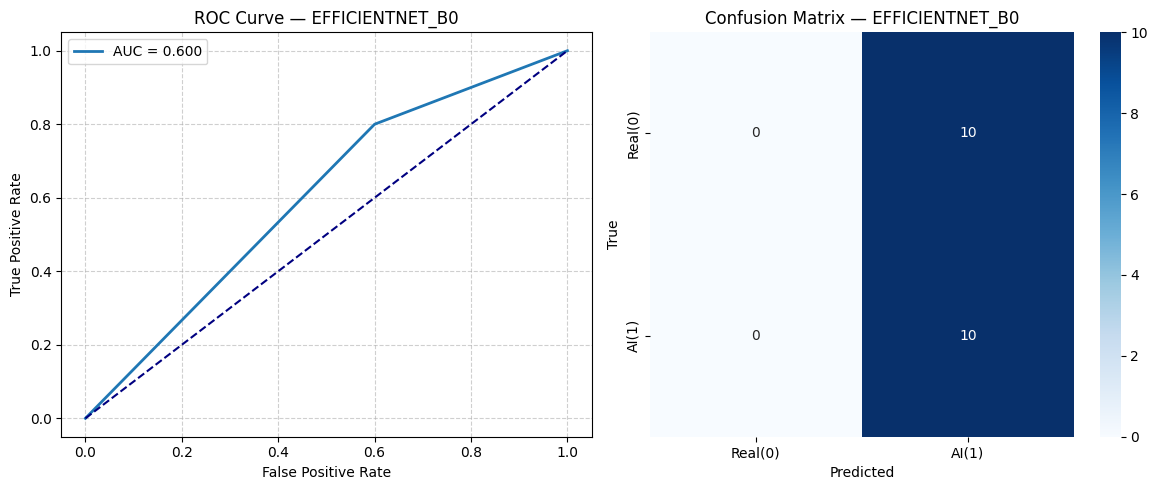

INFO:AIVoiceDetection:Model training complete: efficientnet_b0
INFO:AIVoiceDetection:Starting threshold tuning...
INFO:AIVoiceDetection:============================================================
INFO:AIVoiceDetection:Threshold Tuning for EFFICIENTNET_B0
INFO:AIVoiceDetection:============================================================
INFO:AIVoiceDetection:Creating model: efficientnet_b0
INFO:AIVoiceDetection:Model efficientnet_b0 created successfully
INFO:AIVoiceDetection:Creating dataloaders...
INFO:AIVoiceDetection:Dataset loaded from ./output/spectrogram_images_clean_unique/_splits/train.csv: 160 samples
INFO:AIVoiceDetection:Dataset loaded from ./output/spectrogram_images_clean_unique/_splits/val.csv: 20 samples
INFO:AIVoiceDetection:Dataset loaded from ./output/spectrogram_images_clean_unique/_splits/test.csv: 20 samples
INFO:AIVoiceDetection:Dataloaders created - batch_size: 64
INFO:AIVoiceDetection:ThresholdTuner initialized
INFO:AIVoiceDetection:Finding optimal threshold...



TEST RESULTS (threshold=0.5052)
Accuracy: 0.5000
ROC-AUC: 0.600000

              precision    recall  f1-score   support

     Real(0)       0.50      1.00      0.67        10
       AI(1)       0.00      0.00      0.00        10

    accuracy                           0.50        20
   macro avg       0.25      0.50      0.33        20
weighted avg       0.25      0.50      0.33        20


Confusion Matrix:
[[10  0]
 [10  0]]


INFO:AIVoiceDetection:Results plot saved: output/EFFICIENTNET_B0_(Tuned)_results.png


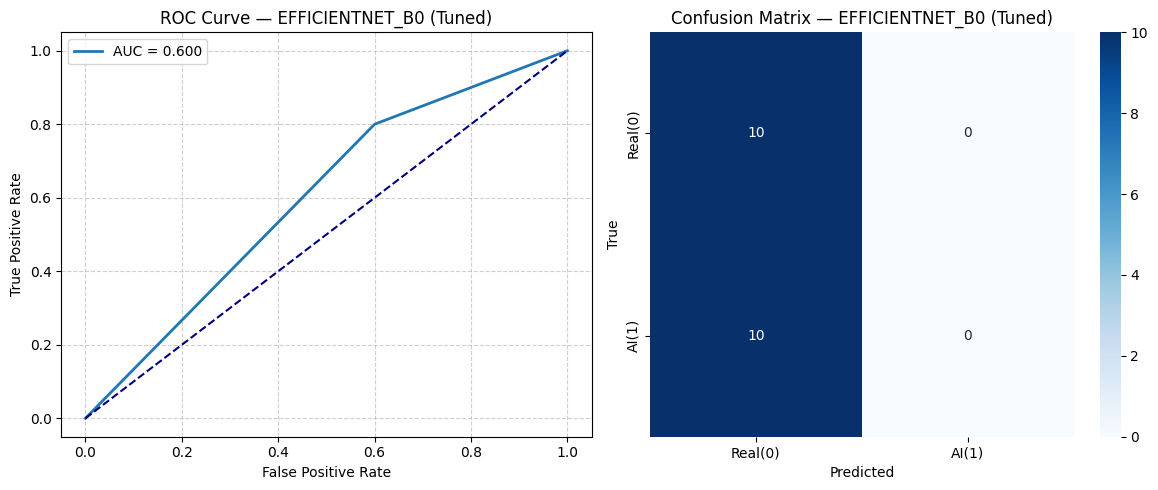

INFO:AIVoiceDetection:Threshold tuning complete: 0.505199
INFO:AIVoiceDetection:Exporting model for inference...
INFO:AIVoiceDetection:Initializing VoiceDetector - Model: ./output/spectrogram_images_clean_unique/best_efficientnet_b0_ai_vs_real.pt
INFO:AIVoiceDetection:Detected model architecture: efficientnet_b0
INFO:AIVoiceDetection:Creating model: efficientnet_b0
INFO:AIVoiceDetection:Model efficientnet_b0 created successfully
INFO:AIVoiceDetection:Model weights loaded successfully
INFO:AIVoiceDetection:VoiceDetector ready - Model: efficientnet_b0, Threshold: 0.5051992535591125
INFO:AIVoiceDetection:Exporting to TorchScript: ./output/spectrogram_images_clean_unique/efficientnet_b0_ai_vs_real.torchscript.pt
INFO:AIVoiceDetection:TorchScript model saved: ./output/spectrogram_images_clean_unique/efficientnet_b0_ai_vs_real.torchscript.pt
INFO:AIVoiceDetection:================================================================================
INFO:AIVoiceDetection:TRAINING WORKFLOW COMPLETE


TorchScript model saved: ./output/spectrogram_images_clean_unique/efficientnet_b0_ai_vs_real.torchscript.pt

Training Complete!
Model: ./output/spectrogram_images_clean_unique/best_efficientnet_b0_ai_vs_real.pt
TorchScript: ./output/spectrogram_images_clean_unique/efficientnet_b0_ai_vs_real.torchscript.pt
Optimal Threshold: 0.505199
Test Accuracy: 0.5000
Test ROC-AUC: 0.600000


In [99]:
# ============================================================================
# MAIN WORKFLOW
# ============================================================================

class WorkflowManager:
    """Manage complete training workflow"""

    def __init__(self):
        logger.info("Initializing WorkflowManager")
        Config.setup_environment()
        self.pipeline = AudioProcessingPipeline()
        self.dataset_builder = DatasetBuilder()
        logger.info("WorkflowManager ready")

    def prepare_data(self):
        """Prepare data: denoise and create spectrograms"""
        logger.info("="*60)
        logger.info("STEP 1: Audio Denoising")
        logger.info("="*60)

        # Process AI audio
        self.pipeline.process_folder(
            Config.AI_DIR,
            os.path.join(Config.CLEAN_DIR, "ai"),
            denoise=True, method="auto"
        )

        # Process Real audio
        self.pipeline.process_folder(
            Config.REAL_DIR,
            os.path.join(Config.CLEAN_DIR, "real"),
            denoise=True, method="auto"
        )

        logger.info("="*60)
        logger.info("STEP 2: Spectrogram Generation")
        logger.info("="*60)

        # Create spectrograms for AI
        self.pipeline.create_spectrograms(
            os.path.join(Config.CLEAN_DIR, "ai"),
            os.path.join(Config.IMG_DIR, "ai")
        )

        # Create spectrograms for Real
        self.pipeline.create_spectrograms(
            os.path.join(Config.CLEAN_DIR, "real"),
            os.path.join(Config.IMG_DIR, "real")
        )

        logger.info("="*60)
        logger.info("STEP 3: Creating Train/Val/Test Splits")
        logger.info("="*60)

        self.dataset_builder.create_splits()
        logger.info("Data preparation complete")

    def train_model(self, model_name: str = "efficientnet_b0") -> str:
        """Train a single model"""
        logger.info(f"{'='*60}")
        logger.info(f"Training {model_name.upper()}")
        logger.info(f"{'='*60}")

        # Create model
        model = ModelFactory.create_model(model_name)

        # Get dataloaders
        dataloaders = self.dataset_builder.get_dataloaders()

        # Train
        save_path = os.path.join(Config.IMG_DIR, f"best_{model_name}_ai_vs_real.pt")
        trainer = Trainer(model)
        trainer.train(dataloaders, save_path=save_path)

        # Evaluate
        logger.info(f"{'='*60}")
        logger.info(f"Evaluating {model_name.upper()} on Test Set")
        logger.info(f"{'='*60}")

        model.load_state_dict(torch.load(save_path, map_location=Config.DEVICE))
        results = Evaluator.evaluate_model(
            model, dataloaders["test"], threshold=0.5
        )
        Evaluator.plot_results(results, title=model_name.upper())

        logger.info(f"Model training complete: {model_name}")
        return save_path

    def tune_and_evaluate(self, model_path: str, model_name: str):
        """Tune threshold and evaluate with optimal threshold"""
        logger.info(f"{'='*60}")
        logger.info(f"Threshold Tuning for {model_name.upper()}")
        logger.info(f"{'='*60}")

        # Load model
        model = ModelFactory.create_model(model_name)
        model.load_state_dict(torch.load(model_path, map_location=Config.DEVICE))

        # Get dataloaders
        dataloaders = self.dataset_builder.get_dataloaders()

        # Tune threshold
        tuner = ThresholdTuner(model)
        best_threshold = tuner.find_optimal_threshold(dataloaders["val"])

        # Evaluate with tuned threshold
        results = Evaluator.evaluate_model(
            model, dataloaders["test"], threshold=best_threshold
        )
        Evaluator.plot_results(results,
                              title=f"{model_name.upper()} (Tuned)")

        logger.info(f"Threshold tuning complete: {best_threshold:.6f}")
        return results, best_threshold


# ============================================================================
# EXAMPLE USAGE
# ============================================================================

def main_training_workflow():
    """Complete training workflow example"""
    logger.info("="*80)
    logger.info("STARTING MAIN TRAINING WORKFLOW")
    logger.info("="*80)

    # Initialize
    workflow = WorkflowManager()

    # Step 1: Prepare data
    logger.info("Starting data preparation...")
    workflow.prepare_data()

    # Step 2: Train model
    logger.info("Starting model training...")
    model_path = workflow.train_model("efficientnet_b0")

    # Step 3: Tune threshold and evaluate
    logger.info("Starting threshold tuning...")
    results, threshold = workflow.tune_and_evaluate(model_path, "efficientnet_b0")

    # Step 4: Export for inference
    logger.info("Exporting model for inference...")
    detector = VoiceDetector(model_path, model_name="efficientnet_b0", threshold=threshold)
    export_path = os.path.join(Config.IMG_DIR, "efficientnet_b0_ai_vs_real.torchscript.pt")
    detector.export_torchscript(export_path)

    logger.info("="*80)
    logger.info("TRAINING WORKFLOW COMPLETE")
    logger.info("="*80)
    logger.info(f"Model: {model_path}")
    logger.info(f"TorchScript: {export_path}")
    logger.info(f"Optimal Threshold: {threshold:.6f}")
    logger.info(f"Test Accuracy: {results['accuracy']:.4f}")
    logger.info(f"Test ROC-AUC: {results['roc_auc']:.6f}")

    print(f"\n{'='*60}")
    print("Training Complete!")
    print(f"Model: {model_path}")
    print(f"TorchScript: {export_path}")
    print(f"Optimal Threshold: {threshold:.6f}")
    print(f"Test Accuracy: {results['accuracy']:.4f}")
    print(f"Test ROC-AUC: {results['roc_auc']:.6f}")
    print("="*60)


def main_inference_example():
    """Inference example"""
    logger.info("="*80)
    logger.info("STARTING INFERENCE EXAMPLE")
    logger.info("="*80)

    # Initialize detector
    model_path = os.path.join(
        Config.IMG_DIR,
        "best_efficientnet_b0_ai_vs_real.pt"
    )
    detector = VoiceDetector(model_path, model_name="efficientnet_b0", threshold=0.9167826771736145)

    # Predict single file
    audio_path = r"C:\path\to\your\audio.wav"
    logger.info(f"Single file prediction: {audio_path}")

    if os.path.exists(audio_path):
        result = detector.predict(audio_path)
    else:
        logger.warning(f"File not found: {audio_path}")

    # Predict multiple files
    audio_files = [
        r"C:\path\to\audio1.wav",
        r"C:\path\to\audio2.wav",
    ]

    existing_files = [f for f in audio_files if os.path.exists(f)]
    if existing_files:
        logger.info(f"Batch prediction: {len(existing_files)} files")
        results = detector.predict_batch(existing_files)

        # Print summary
        logger.info("Prediction summary:")
        for r in results:
            if "error" not in r:
                logger.info(f"{r['label']}: {r['prob_ai']:.4f} - {r['path']}")
                print(f"{r['label']}: {r['prob_ai']:.4f} - {r['path']}")
    else:
        logger.warning("No valid audio files found for batch prediction")

    logger.info("="*80)
    logger.info("INFERENCE EXAMPLE COMPLETE")
    logger.info("="*80)


def main():
    """
    Main function with menu-driven interface
    Choose between:
    1. Complete training workflow (data prep + training + evaluation)
    2. Only data preparation
    3. Only model training
    4. Only threshold tuning and evaluation
    5. Inference on new audio files
    """
    logger.info("="*80)
    logger.info("AI vs Real Voice Detection System Started")
    logger.info("="*80)

    print("\n" + "="*60)
    print("AI vs REAL VOICE DETECTION SYSTEM")
    print("="*60)
    print("\nSelect an option:")
    print("1. Complete Training Workflow (Data Prep + Training + Evaluation)")
    print("2. Data Preparation Only (Denoise + Spectrograms + Splits)")
    print("3. Model Training Only")
    print("4. Threshold Tuning & Evaluation")
    print("5. Inference on New Audio Files")
    print("6. Exit")
    print("="*60)

    try:
        #choice = input("\nEnter your choice (1-6): ").strip()
        choice="1"
        logger.info(f"User selected option: {choice}")

        if choice == "1":
            # Complete workflow
            logger.info("Starting complete training workflow")
            main_training_workflow()

        elif choice == "2":
            # Data preparation only
            logger.info("Starting data preparation only")
            workflow = WorkflowManager()
            workflow.prepare_data()
            print("\n✓ Data preparation complete!")
            logger.info("Data preparation completed successfully")

        elif choice == "3":
            # Model training only
            logger.info("Starting model training only")
            print("\nAvailable models:")
            models = ["resnet18", "efficientnet_b0", "efficientnet_b1",
                     "densenet121", "densenet169", "mobilenet_v3_small",
                     "convnext_tiny", "vit_b16", "swin_tiny"]
            for i, m in enumerate(models, 1):
                print(f"{i}. {m}")

            model_choice = input("\nSelect model number (default: 2 for efficientnet_b0): ").strip()
            model_idx = int(model_choice) - 1 if model_choice.isdigit() else 1
            model_name = models[model_idx] if 0 <= model_idx < len(models) else "efficientnet_b0"

            logger.info(f"Training model: {model_name}")
            workflow = WorkflowManager()
            model_path = workflow.train_model(model_name)
            print(f"\n✓ Model trained and saved to: {model_path}")
            logger.info(f"Model training completed: {model_path}")

        elif choice == "4":
            # Threshold tuning only
            logger.info("Starting threshold tuning")
            model_path = input("\nEnter model path (or press Enter for default): ").strip()
            if not model_path:
                model_path = os.path.join(Config.IMG_DIR, "best_efficientnet_b0_ai_vs_real.pt")

            if not os.path.exists(model_path):
                print(f"✗ Model not found: {model_path}")
                logger.error(f"Model file not found: {model_path}")
                return

            model_name = input("Enter model name (default: efficientnet_b0): ").strip() or "efficientnet_b0"

            workflow = WorkflowManager()
            results, threshold = workflow.tune_and_evaluate(model_path, model_name)
            print(f"\n✓ Optimal threshold: {threshold:.6f}")
            print(f"✓ Test Accuracy: {results['accuracy']:.4f}")
            print(f"✓ Test ROC-AUC: {results['roc_auc']:.6f}")
            logger.info(f"Threshold tuning completed: {threshold:.6f}")

        elif choice == "5":
            # Inference
            logger.info("Starting inference mode")

            # Get model path
            model_path = input("\nEnter model path (or press Enter for default): ").strip()
            if not model_path:
                model_path = os.path.join(Config.IMG_DIR, "best_efficientnet_b0_ai_vs_real.pt")

            if not os.path.exists(model_path):
                print(f"✗ Model not found: {model_path}")
                logger.error(f"Model file not found: {model_path}")
                return

            # Get model name
            model_name = input("Enter model name (default: efficientnet_b0): ").strip() or "efficientnet_b0"

            # Get threshold
            threshold_input = input("Enter threshold (default: 0.5): ").strip()
            threshold = float(threshold_input) if threshold_input else 0.5

            # Initialize detector
            detector = VoiceDetector(model_path, model_name=model_name, threshold=threshold)

            # Choose between single or batch
            print("\n1. Single file prediction")
            print("2. Batch prediction (folder)")
            pred_choice = input("Enter choice (1-2): ").strip()

            if pred_choice == "1":
                # Single file
                audio_path = input("\nEnter audio file path: ").strip()
                if os.path.exists(audio_path):
                    result = detector.predict(audio_path)
                    print(f"\n{'='*60}")
                    print(f"PREDICTION RESULT")
                    print(f"{'='*60}")
                    print(f"File: {result['path']}")
                    print(f"Probability (AI): {result['prob_ai']:.6f}")
                    print(f"Threshold: {result['threshold']:.3f}")
                    print(f"Prediction: {result['label']}")
                    print(f"{'='*60}")
                else:
                    print(f"✗ File not found: {audio_path}")
                    logger.warning(f"Audio file not found: {audio_path}")

            elif pred_choice == "2":
                # Batch prediction
                folder_path = input("\nEnter folder path: ").strip()
                if os.path.exists(folder_path):
                    audio_files = FileUtils.list_audio_files(folder_path)
                    if audio_files:
                        print(f"\nFound {len(audio_files)} audio files. Processing...")
                        results = detector.predict_batch(audio_files)

                        # Summary
                        print(f"\n{'='*60}")
                        print(f"BATCH PREDICTION RESULTS")
                        print(f"{'='*60}")
                        ai_count = sum(1 for r in results if r.get('label') == 'AI voice')
                        real_count = sum(1 for r in results if r.get('label') == 'Real voice')
                        error_count = sum(1 for r in results if 'error' in r)

                        print(f"Total files: {len(results)}")
                        print(f"AI voices detected: {ai_count}")
                        print(f"Real voices detected: {real_count}")
                        print(f"Errors: {error_count}")
                        print(f"{'='*60}\n")

                        # Detailed results
                        for r in results:
                            if "error" not in r:
                                print(f"{r['label']:12s} | Prob: {r['prob_ai']:.4f} | {os.path.basename(r['path'])}")
                            else:
                                print(f"ERROR        | {os.path.basename(r['path'])}: {r['error']}")
                    else:
                        print("✗ No audio files found in folder")
                        logger.warning(f"No audio files in folder: {folder_path}")
                else:
                    print(f"✗ Folder not found: {folder_path}")
                    logger.warning(f"Folder not found: {folder_path}")

            logger.info("Inference completed")

        elif choice == "6":
            print("\nExiting...")
            logger.info("User exited the program")
            return
        else:
            print("\n✗ Invalid choice. Please run again.")
            logger.warning(f"Invalid menu choice: {choice}")
            return

        logger.info("="*80)
        logger.info("Program completed successfully")
        logger.info("="*80)

    except KeyboardInterrupt:
        print("\n\n✗ Program interrupted by user")
        logger.warning("Program interrupted by user (KeyboardInterrupt)")
    except Exception as e:
        print(f"\n✗ Error occurred: {e}")
        logger.exception(f"Fatal error occurred: {e}")
        raise


if __name__ == "__main__":
    main()

In [100]:
import os
import subprocess
import sys

def setup_colab():
    """Helper function to set up Google Colab environment"""

    print("Setting up Google Colab environment...")

    # Install system-level packages
    try:
        subprocess.check_call(['apt-get', 'update'])
        subprocess.check_call(['apt-get', 'install', '-y', 'ffmpeg'])
        print("✓ Installed ffmpeg")
    except subprocess.CalledProcessError:
        print("✗ Failed to install ffmpeg")

    # Install required Python packages
    packages = [
        'librosa',
        'soundfile',
        'torchaudio',
        'seaborn',
        'tqdm',
        'demucs'
    ]

    for package in packages:
        try:
            subprocess.check_call([sys.executable, "-m", "pip", "install", package])
            print(f"✓ Installed {package}")
        except subprocess.CalledProcessError:
            print(f"✗ Failed to install {package}")

    # Create directory structure
    os.makedirs('./dataset/ai', exist_ok=True)
    os.makedirs('./dataset/real', exist_ok=True)
    os.makedirs('./output', exist_ok=True)

    print("✓ Created directory structure")
    print("✓ Colab setup complete!")
    print("\nNext steps:")
    print("1. Upload your AI audio files to ./dataset/ai/")
    print("2. Upload your Real audio files to ./dataset/real/")
    print("3. Run main() to start the application")

setup_colab()
print("Current working directory:", os.getcwd())

Setting up Google Colab environment...
✓ Installed ffmpeg
✓ Installed librosa
✓ Installed soundfile
✓ Installed torchaudio
✓ Installed seaborn
✓ Installed tqdm
✓ Installed demucs
✓ Created directory structure
✓ Colab setup complete!

Next steps:
1. Upload your AI audio files to ./dataset/ai/
2. Upload your Real audio files to ./dataset/real/
3. Run main() to start the application
Current working directory: /content


In [101]:
print("Using device:", Config.DEVICE)

Using device: cuda


In [102]:
import torch
print(torch.cuda.is_available())  # Should return True
print(torch.cuda.get_device_name(0))  # Should print GPU name

True
Tesla T4


In [103]:
!rm -rf ./output